# AI 서비스 개발을 위한 딥러닝 자연어 처리

In [ ]:
import nltk

In [ ]:
from nltk.corpus import brown as cb
from nltk.corpus import gutenberg as gb

In [ ]:
nltk.download('brown')
nltk.download('gutenberg')

In [ ]:
cb.fileids()[:10]

In [ ]:
gb.fileids()

In [ ]:
cb.categories()

In [ ]:
print('brown corpus 총 단어수 =', len(cb.words()))
print(cb.words())
print('Gutenberg corpus 총 단어수 =', len(gb.words()))
print(gb.words())

In [ ]:
cb.words?

In [ ]:
cb.words(categories='adventure')

In [ ]:
cb.words(fileids='ca01')

In [ ]:
gb.words(fileids='austen-emma.txt')

In [ ]:
raw_text = cb.raw(fileids='ca01')
raw_text

In [ ]:
raw_text = gb.raw(fileids='austen-emma.txt')
print(raw_text)

In [ ]:
# sentence tokenize
from nltk.tokenize import sent_tokenize

In [ ]:
raw_text = gb.raw(fileids='austen-emma.txt')

In [ ]:
sents = sent_tokenize(raw_text)
sents[0]

In [ ]:
from nltk.tokenize import word_tokenize

In [ ]:
tokens = word_tokenize(sents[0])

In [ ]:
from nltk.tokenize import WordPunctTokenizer

In [ ]:
wpt = WordPunctTokenizer()
wpt.tokenize(sents[0])

In [ ]:
from nltk.stem import PorterStemmer

In [ ]:
ps = PorterStemmer()
ps.stem('lived')

# word2vec

[02) 워드투벡터(Word2Vec)](https://wikidocs.net/22660)  

In [ ]:
!pip install lxml
!pip install nltk
!pip install pandas
!pip install matplotlib
!pip install gensim
!pip install konlpy

In [ ]:
import nltk
nltk.download('punkt')

In [ ]:
import urllib.request
import zipfile
from lxml import etree
import re
from nltk.tokenize import word_tokenize, sent_tokenize

In [ ]:
#urllib.request.urlretrieve(
#    "https://raw.githubusercontent.com/GaoleMeng/RNN-and-FFNN-textClassification/master/ted_en-20160408.xml",
#    filename="ted_en-20160408.xml")
!wget "https://raw.githubusercontent.com/GaoleMeng/RNN-and-FFNN-textClassification/master/ted_en-20160408.xml"

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
from gensim.models.word2vec import Word2Vec
from konlpy.tag import Okt

In [ ]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt", filename="ratings.txt")

In [ ]:
train_data = pd.read_table('ratings.txt')
train_data[:5]

In [ ]:
print(len(train_data)) # 리뷰 개수 출력

In [ ]:
train_data = train_data.dropna(how = 'any') # Null 값이 존재하는 행 제거
print(train_data.isnull().values.any()) # Null 값이 존재하는지 확인
print(len(train_data)) # 리뷰 개수 출력

In [ ]:
# 정규 표현식을 통한 한글 외 문자 제거
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)
train_data[:5] # 상위 5개 출력

In [ ]:
# 불용어 정의
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

In [ ]:
from tqdm import tqdm

# 형태소 분석기 OKT를 사용한 토큰화 작업 (다소 시간 소요)
okt = Okt()
tokenized_data = []
for sentence in tqdm(train_data['document']):
    temp_X = okt.morphs(sentence, stem=True) # 토큰화
    temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
    tokenized_data.append(temp_X)

In [ ]:
sentence = train_data['document'][1]
temp_X = okt.morphs(sentence, stem=True) # 토큰화
temp_X

In [ ]:
sentence

In [ ]:
# 리뷰 길이 분포 확인
print('리뷰의 최대 길이 :',max(len(l) for l in tokenized_data))
print('리뷰의 평균 길이 :',sum(map(len, tokenized_data))/len(tokenized_data))
plt.hist([len(s) for s in tokenized_data], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [ ]:
from gensim.models import Word2Vec
model = Word2Vec(sentences = tokenized_data, size = 100, window = 5, min_count = 5, workers = 4, sg = 0)

In [ ]:
# 완성된 임베딩 매트릭스의 크기 확인
model.wv.vectors.shape

In [ ]:
print(model.wv.most_similar("태극기"))

# word2vec 응용

[Word2Vec 그리고
추천 시스템의 Item2Vec](https://brunch.co.kr/@goodvc78/16?fbclid=IwAR1QZZAeZe_tNWxnxVCRwl8PIouBPAaqSIJ1lBxJ-EKtfDfmLehi1MUV_Lk)  

# SVD

In [ ]:
import numpy as np
A = np.array([
    [2, 0, 8, 6, 0],
    [1, 6, 0, 1, 7],
    [5, 0, 7, 4, 0],
    [7, 0, 8, 5, 0],
    [0,10, 0, 0, 7],
])

In [ ]:
A = np.array([
    [ 3, 1, 1],
    [-1, 3, 1]
])

In [ ]:
A = np.array([
    [2, 4],
    [1, 3],
    [0, 0],
    [0, 0],
])

In [ ]:
At = np.transpose(A)
AAt = np.matmul(A, At)
AtA = np.matmul(At, A)

In [ ]:
e1,u = np.linalg.eig(AAt)
e2,v = np.linalg.eig(AtA)

In [ ]:
# sorting
# [::-1] reverses the arrary 
#inx1 = np.argsort(e1)[::-1]
#inx2 = np.argsort(e2)[::-1]
inx1 = np.argsort(-e1)
inx2 = np.argsort(-e2)

evalue, U = e1[inx1], u[:, inx1]
e2value, V = e2[inx2], v[:, inx2]

In [ ]:
# for all positive 
n = np.sum(evalue > 0)

for i in range(n):
    inner = np.dot(U[:, i], np.matmul(A, V)[:, i]/np.sqrt(evalue[i]))
    sign = np.sign(inner)
    U[:, i] = sign*U[:, i]

In [ ]:
VT = np.transpose(V)

In [ ]:
S = np.zeros(A.shape)
for i in range(min(len(evalue), len(e2))):
    S[i,i] = np.sqrt(evalue[i])

In [ ]:
A_reconstructed = np.matmul(U, np.matmul(S, VT))
A_reconstructed, A

## Proof of the Singular Value Decomposition

http://gregorygundersen.com/blog/2018/12/20/svd-proof/  

[Singular Value Decomposition Part 2: Theorem, Proof, Algorithm](https://jeremykun.com/2016/05/16/singular-value-decomposition-part-2-theorem-proof-algorithm/)  
https://github.com/j2kun/svd  

In [ ]:
from numpy.linalg import svd
 
movieRatings = [
    [2, 5, 3],
    [1, 2, 1],
    [4, 1, 1],
    [3, 5, 2],
    [5, 3, 1],
    [4, 5, 5],
    [2, 4, 2],
    [2, 2, 5],
]
 
U, singularValues, V = svd(movieRatings)

In [ ]:
U, singularValues, V

[Comprehensive Guide to build a Recommendation Engine from scratch (in Python)](https://www.analyticsvidhya.com/blog/2018/06/comprehensive-guide-recommendation-engine-python/?utm_source=blog&utm_medium=5-applications-singular-value-decomposition-svd-data-science)  

# doc2vec

https://medium.com/@klintcho/doc2vec-tutorial-using-gensim-ab3ac03d3a1  

https://radimrehurek.com/gensim/auto_examples/tutorials/run_doc2vec_lee.html#sphx-glr-auto-examples-tutorials-run-doc2vec-lee-py  

[doc2vec 훈련 파라미터 설명](https://roboreport.co.kr/doc2vec-%ED%9B%88%EB%A0%A8-%ED%8C%8C%EB%9D%BC%EB%AF%B8%ED%84%B0-%EC%84%A4%EB%AA%85/)  

# demo

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
!pip list | grep matplot

In [ ]:
!pip install ipympl

In [ ]:
vectors = np.array(([2, 0], [3, 2]))
vector_addition = vectors[0] + vectors[1]
vectors = np.append(vectors, vector_addition[None,:], axis=0)
 
tail = [0, 0]
fig, ax = plt.subplots(1)
#ax.quiver([[0,0], [0,0]], [[1,1], [2,2]])
#x_pos = 0
x_pos = [0, 0]
y_pos = [0, 0]
x_direct = [2, 0]
y_direct = [2, -2]

x_pos = [0, -0.5]
y_pos = [0, 0.5]
x_direct = [1.0, 0.]
y_direct = [1.0, -1.0]

#ax.quiver(x_pos,y_pos,x_direct,y_direct, color=['r', 'k'], scale=0.5, scale_units='xy')
ax.quiver(x_pos,y_pos,x_direct,y_direct, color=['r', 'k'], scale=1, scale_units='xy')
x_pos = [1, 0.5]
y_pos = [0, 0.5]
quiver_data = ax.quiver(x_pos,y_pos,x_direct,y_direct, color=['g', 'gray'], width=0.005, scale=1, scale_units='xy')
#ax.axis([-100,100,-100,100])
ax.axis([-3,3,-3,3])
ax.axhline(0)
ax.axvline(0)
plt.show()


In [ ]:
quiver_data?

In [ ]:
%matplotlib widget

In [ ]:
#ax.quiver(*tail,
#plt.ioff()
#plt.figure()
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.quiver([0,0,0], [0,0,0],
           vectors[:, 0],
           vectors[:, 1],
           scale=1,
           scale_units='xy',
           angles = 'xy',
           color=['g', 'r', 'k'])
ax2.quiver([0,0,0], [0,0,0],
           vectors[:, 0],
           vectors[:, 1],
           scale=1,
           scale_units='xy',
           angles = 'xy',
           color=['g', 'r', 'k'])
plt.show()

In [ ]:
# Testing matplotlib interactions with a simple plot
fig = plt.figure()
plt.plot(np.sin(np.linspace(0, 20, 100)));

In [ ]:
%matplotlib widget

In [ ]:
plt.show()

In [ ]:
# Enabling the `widget` backend.
# This requires jupyter-matplotlib a.k.a. ipympl.
# ipympl can be install via pip or conda.
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np



In [ ]:
# Testing matplotlib interactions with a simple plot
fig = plt.figure()
plt.plot(np.sin(np.linspace(0, 20, 100)));

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt


def press(event):
    print('press', event.key)
    sys.stdout.flush()
    if event.key == 'x':
        visible = xl.get_visible()
        xl.set_visible(not visible)
        fig.canvas.draw()

# Fixing random state for reproducibility
np.random.seed(19680801)


fig, ax = plt.subplots()

fig.canvas.mpl_connect('key_press_event', press)

ax.plot(np.random.rand(12), np.random.rand(12), 'go')
xl = ax.set_xlabel('easy come, easy go')
ax.set_title('Press a key')
plt.show()

**some example**  
https://blog.dominodatalab.com/interactive-dashboards-in-jupyter/  
(old source)

In [ ]:
%matplotlib notebook
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import *
from IPython.display import display
from ipywidgets import widgets
plt.style.use('ggplot')
 
NUMBER_OF_PINGS = 4
 
# displaying the text widget
text = widgets.Text(description="Domain to ping", width=200)
display(text)
 
# preparing the plot
data = pd.DataFrame()
x = range(1,NUMBER_OF_PINGS+1)
plots = dict()
fig, ax = plt.subplots()
plt.xlabel('iterations')
plt.ylabel('ms')
plt.xticks(x)
plt.show()
 
# preparing a container to put in created checkbox per domain
checkboxes = []
cb_container = widgets.HBox()
display(cb_container)
 
# add button that updates the graph based on the checkboxes
button = widgets.Button(description="Update the graph")
display(button)
 
# function to deal with the added domain name
def handle_submit(sender):
    global plots
    # a part of the magic inside python : pinging
    res = !ping -c {NUMBER_OF_PINGS} {text.value}
    hits = res.grep('64 bytes').fields(-2).s.replace("time=","").split()
    if len(hits) == 0:
        print("Domain gave error on pinging")
    else:
        # rebuild plot based on ping result
        data = hits
        #print(hits)
        #data = data.astype(float)
        #print(len(x))
        #print(len(data))
        #print(data)
        plots, = ax.plot(x, data, label=text.value)
        plt.legend()
        plt.draw()
    
        # add a new checkbox for the new domain
        checkboxes.append(widgets.Checkbox(description = text.value, value=True, width=90))
        cb_container.children=[i for i in checkboxes]
        if len(checkboxes) == 1:
            display(button)
 
# function to deal with the checkbox update button
def on_button_clicked(b):
    for c in cb_container.children:
        if not c.value:
            plots.set_visible(False)
        else:
            plots.set_visible(True)
        plt.legend()
        plt.draw()
 
button.on_click(on_button_clicked)
text.on_submit(handle_submit)
plt.show()

# interactive python

https://blog.dominodatalab.com/interactive-dashboards-in-jupyter/  

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact

In [25]:
from ipywidgets import widgets
from IPython.display import display

text = widgets.Text()
display(text)

def handle_submit(sender):
    print(text.value)

text.on_submit(handle_submit)

Text(value='')

/tmp/ipykernel_3382369/3862560053.py:10: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  text.on_submit(handle_submit)


In [26]:
button = widgets.Button(description='Click me')
display(button)

def on_button_clicked(b):
    print('button clicked')

button.on_click(on_button_clicked)

Button(description='Click me', style=ButtonStyle())

In [28]:
def f(x):
    print(x)

interact(f, x=10)

interactive(children=(IntSlider(value=10, description='x', max=30, min=-10), Output()), _dom_classes=('widget-…

<function __main__.f(x)>

In [31]:
interact(f, x=True)

interactive(children=(Checkbox(value=True, description='x'), Output()), _dom_classes=('widget-interact',))

<function __main__.f(x)>

In [32]:
interact(f, x='text')

interactive(children=(Text(value='text', description='x'), Output()), _dom_classes=('widget-interact',))

<function __main__.f(x)>

In [33]:
outputText = widgets.Text()
display(outputText)

Text(value='')

In [34]:
inputText = widgets.Text()
display(inputText)

def makeUpperCase(sender):
    outputText.value = inputText.value.upper()

inputText.on_submit(makeUpperCase)

Text(value='')

/tmp/ipykernel_3382369/4214555702.py:7: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  inputText.on_submit(makeUpperCase)


In [35]:
%matplotlib inline
t = np.arange(0.0, 1.0, 0.01)
def pltsin(f):
    plt.plot(t, np.sin(2*np.pi*t*f))
    plt.show()

interact(pltsin, f=(1,10,0.1))

interactive(children=(FloatSlider(value=5.0, description='f', max=10.0, min=1.0), Output()), _dom_classes=('wi…

<function __main__.pltsin(f)>

In [12]:
%matplotlib inline

t = np.arange(0.0, 1.0, 0.01)

def pltsin(f):
    ax.plot(t, np.sin(2*np.pi*t*f))
    #fig.canvas.draw()
    plt.show()

fig, ax = plt.subplots(1)
interact(pltsin, f=(1,10,0.1))

interactive(children=(FloatSlider(value=5.0, description='f', max=10.0, min=1.0), Output()), _dom_classes=('wi…

<function __main__.pltsin(f)>

**changing data only**

interactive(children=(FloatSlider(value=1.0, description='w', max=3.0, min=-1.0), Output()), _dom_classes=('wi…

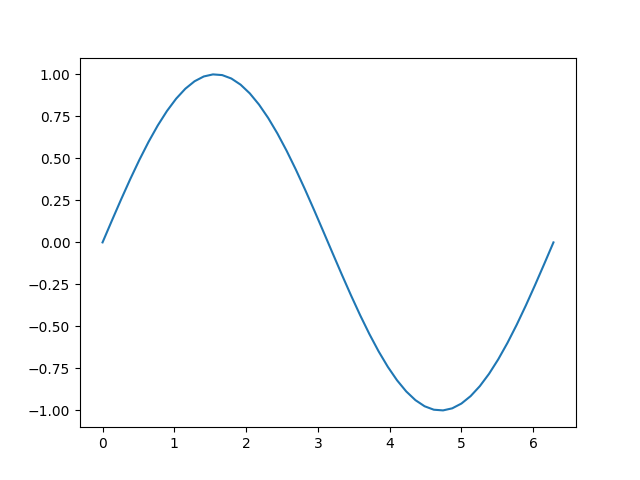

In [36]:
%matplotlib widget
from ipywidgets import interact
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi)
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
line, = ax.plot(x, np.sin(x))

def update(w = 1.0):
    print(w)
    line.set_ydata(np.sin(w * x))
    fig.canvas.draw_idle()

interact(update);

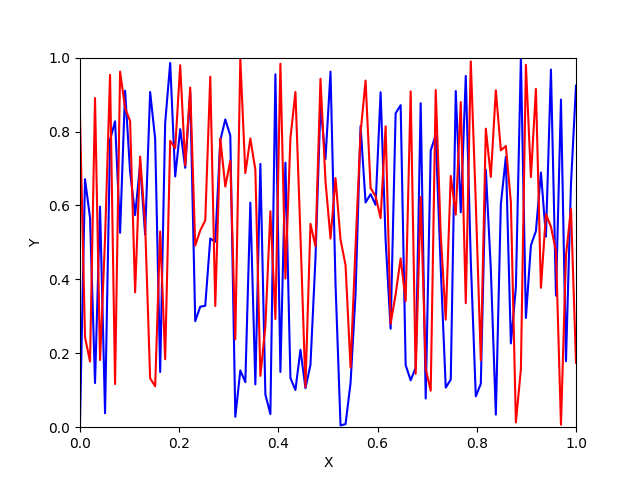

In [21]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import time

def pltsin(ax, colors=['b']):
    x = np.linspace(0,1,100)
    if ax.lines:
        for line in ax.lines:
            line.set_xdata(x)
            y = np.random.random(size=(100,1))
            line.set_ydata(y)
    else:
        for color in colors:
            y = np.random.random(size=(100,1))
            ax.plot(x, y, color)
    fig.canvas.draw()

fig,ax = plt.subplots(1,1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_xlim(0,1)
ax.set_ylim(0,1)
for f in range(5):
    pltsin(ax, ['b', 'r'])
    time.sleep(1)

# simulation

In [37]:
import numpy as np
from ipywidgets.widgets import FloatSlider
import matplotlib.pyplot as plt
from matplotlib import patches, lines
from ipywidgets import interact

In [38]:
%matplotlib widget

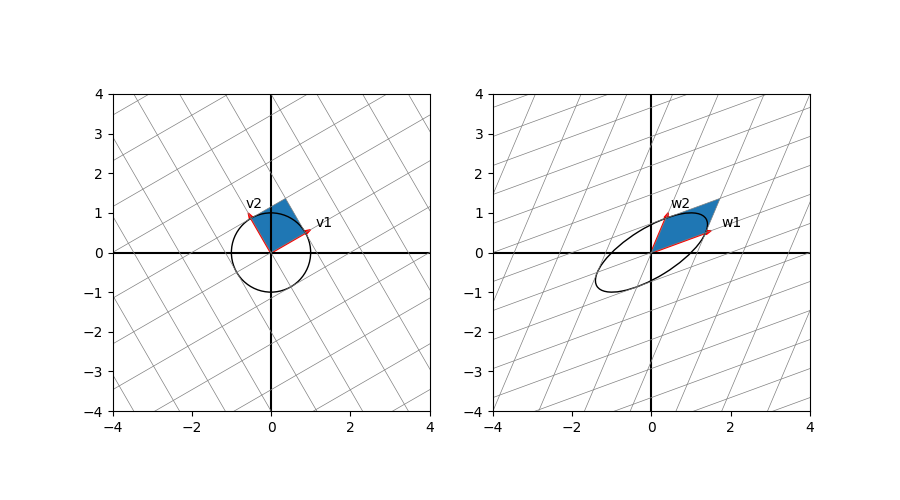

interactive(children=(FloatSlider(value=0.0, description='degree', max=360.0, step=1.0), Output()), _dom_class…

<function __main__.plotall(degree)>

In [41]:
e1 = np.array([1,0])
e2 = np.array([0,1])

degree = 30.

def rot(degree):
    angle = 2*np.pi/360*degree
    return np.array([
        [ np.cos(angle), -np.sin(angle) ],
        [ np.sin(angle), np.cos(angle) ],
    ])

R = rot(degree)
v1 = np.matmul(R, e1)
v2 = np.matmul(R, e2)
I = np.array( [
        [1, 0],
        [0, 1]
] )
A1 = np.array( [
        [3, 0],
        [0, 1]
] )
A2 = np.array( [
        [2, 1],
        [1, 2]
] )
A = np.array( [
        [1, 0.2],
        [0, 1]
] )
A3 = np.array( [
        [1, 1],
        [0, 1]
] )
A4 = np.array( [
        [1, 1],
        [2, 2]
] )
A = A3

# drawing ellipse flag
draw_ellipse = True
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(9,5))

graph_range = 4
ngrid = graph_range*2
text_loc = 1.3

def draw_vectors(ax, u1, u2, M, prefix):
    ax.axis([-graph_range,graph_range,-graph_range,graph_range])
    ax.set_aspect('equal')
    ax.axhline(0, color='k')
    ax.axvline(0, color='k')
    arrow1 = ax.arrow(0,0,u1[0], u1[1], width=0.03, head_width=0.1, color='r')
    arrow2 = ax.arrow(0,0,u2[0], u2[1], width=0.03, head_width=0.1, color='r')
    pgram = patches.Polygon([[0,0], u1, u1+u2, u2])
    ax.add_patch(pgram)
    #w,v = np.linalg.eig(np.matmul(np.transpose(M), M))
    #print(w,v)
    w,v = np.linalg.eig(np.matmul(M, np.transpose(M)))
    if v[0,0] == 0.:
        angle = np.pi/2
    else:
        # column vector of v is the eigenvector. 
        angle = np.arctan(v[1,0]/v[0,0])
    degree = angle/(2*np.pi)*360
    ellip = None
    if draw_ellipse:
        ellip = patches.Ellipse([0,0], width=2*np.sqrt(w[0]), height=2*np.sqrt(w[1]), angle=degree, fill=False, color='k')
        ax.add_patch(ellip)
    text1 = ax.text(u1[0]*text_loc, u1[1]*text_loc, prefix+'1')
    text2 = ax.text(u2[0]*text_loc, u2[1]*text_loc, prefix+'2')
    grid1 = []
    grid2 = []
    for i in range(-ngrid, ngrid+1):
        p1 = i*u1-ngrid*u2
        p2 = i*u1+ngrid*u2
        grid = lines.Line2D([p1[0], p2[0]], [p1[1], p2[1]], linewidth=0.5, color='gray')
        grid1.append(grid)
        ax.add_line(grid)
        p1 = i*u2-ngrid*u1
        p2 = i*u2+ngrid*u1
        grid = lines.Line2D([p1[0], p2[0]], [p1[1], p2[1]], linewidth=0.5, color='gray')
        grid2.append(grid)
        ax.add_line(grid)
    return arrow1, arrow2, pgram, ellip, text1, text2, grid1, grid2
    
vdata = draw_vectors(ax1, v1, v2, I, 'v')

w1 = np.matmul(A, v1)
w2 = np.matmul(A, v2)
wdata = draw_vectors(ax2, w1, w2, A, 'w')

plt.show()

def plotvec(degree, ax, data, u1, u2):
    arrow1, arrow2, pgram, ellip, text1, text2, grid1, grid2 = data
    #ax.remove(arrow1)
    arrow1.remove()
    arrow2.remove()
    arrow1 = ax.arrow(0,0,u1[0], u1[1], width=0.03, head_width=0.1, color='r')
    arrow2 = ax.arrow(0,0,u2[0], u2[1], width=0.03, head_width=0.1, color='r')
    pgram.set_xy([[0,0], u1, u1+u2, u2])
    text1.set_position(u1*text_loc)
    text2.set_position(u2*text_loc)
    for ind, i in enumerate(range(-ngrid, ngrid+1)):
        p1 = i*u1-ngrid*u2
        p2 = i*u1+ngrid*u2
        grid1[ind].set_data([p1[0],p2[0]], [p1[1], p2[1]])
        p1 = i*u2-ngrid*u1
        p2 = i*u2+ngrid*u1
        grid2[ind].set_data([p1[0],p2[0]], [p1[1], p2[1]])
    return arrow1, arrow2, pgram, ellip, text1, text2, grid1, grid2

def plotall(degree):
    global vdata, wdata
    v1 = np.matmul(rot(degree), e1)
    v2 = np.matmul(rot(degree), e2)
    w1 = np.matmul(A, v1)
    w2 = np.matmul(A, v2)
    vdata = plotvec(degree, ax1, vdata, v1, v2)
    wdata = plotvec(degree, ax2, wdata, w1, w2)
    #plotvec(degree, ax2, wdata)

#interact(plotvec, degree=(0,360,1))
interact(plotall, degree=FloatSlider(min=0, max=360, step=1, value=0))
    



**Image compression**

In [ ]:
A = np.array([
   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
   [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], 
   [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1], 
   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
])

plt.figure()
plt.imshow(A, cmap='gray')
plt.show()

In [ ]:
from sklearn.decomposition import TruncatedSVD

k=3
n_iters=10
svd = TruncatedSVD(n_components=k, n_iter=n_iters)
svd.fit(A)

In [ ]:
A_reduced = svd.transform(A)

In [ ]:
A_reduced

In [ ]:
A_compressed = svd.inverse_transform(A_reduced)

In [ ]:
plt.figure()
plt.imshow(A_compressed, cmap='gray')
plt.show()

In [ ]:
noise = np.random.rand(*A.shape)*0.1-0.05

In [ ]:
A_noise = A+noise

In [ ]:
plt.figure()
plt.imshow(A_noise, cmap='gray')
plt.show()

In [ ]:
k=3
n_iters=10
svd = TruncatedSVD(n_components=k, n_iter=n_iters)
svd.fit(A_noise)
A_reprod = svd.inverse_transform(svd.transform(A_noise))

In [ ]:
plt.figure()
plt.imshow(A_reprod, cmap='gray')
plt.show()

**Simple SVD test** 

In [ ]:
import numpy as np
from ipywidgets.widgets import FloatSlider
import matplotlib.pyplot as plt
from matplotlib import patches, lines
from ipywidgets import interact

In [ ]:
A = np.array([
   [1, 0, 0], # person A
   [1, 0, 0], # person B
   [1, 0, 0], # person B
   [0, 1, 0], # person C
   [0, 0, 1], # person D
])

plt.figure()
plt.imshow(A, cmap='binary')
plt.show()

In [ ]:
from numpy.linalg import svd
 
U, singularValues, V = svd(A)


In [ ]:
singularValues

In [ ]:
U

In [ ]:
V

In [ ]:
U

In [ ]:
A = np.array([
   [2, 0, 0], # person A
   [0, 1, 0], # person C
   [0, 0, 1], # person D
])

plt.figure()
plt.imshow(A, cmap='binary')
plt.show()

In [ ]:
from numpy.linalg import svd
 
U, singularValues, V = svd(A)

In [ ]:
singularValues

In [ ]:
U, V